# Análisis Estadístico y Validación de Hipótesis

1. **Validación de Normalidad:** ¿Siguen los retornos una campana de Gauss?
2. **Análisis de Momentos:** Identificación de sesgos y eventos extremos (Colas Pesadas).
3. **Significancia de Correlaciones:** Cálculo de p-values para el sector bancario (H2).
4. **Exportación Final:** Preparación de datos validados para SQL y Tableau.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sys 
sys.path.append('..')
from funciones import test_normalidad, imprimir_reporte_normalidad, graficar_distribucion, analizar_sector_normalidad, graficar_comparativa_sectores, graficar_matriz_correlacion

# Configuración estética
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Carga de retornos ya limpios
df_precios = pd.read_csv('../Datos/ibex35_precios.csv', index_col='Date', parse_dates=True)
df_retornos = df_precios.pct_change().dropna()
df_comp = pd.read_csv('../Datos/ibex35_componentes.csv')

print("✅ Datos cargados y listos para el análisis estadístico.")

✅ Datos cargados y listos para el análisis estadístico.


## Test de Normalidad:
**Objetivo:** Determinar si los retornos de los activos siguen una distribución normal. En finanzas, la normalidad es una asunción crítica; si se viola (Fat Tails), el riesgo real de pérdida es mucho mayor al predicho por modelos básicos.

- Hipótesis Nula (H0): Los retornos analizados provienen de una población con una distribución normal. Bajo la aceptación de H0, las métricas de rentabilidad y riesgo guardan una relación lineal (Gaussiana), lo que permite la aplicación de modelos financieros clásicos (como el Ratio de Sharpe o la Optimización de Markowitz) con un nivel de confianza estandarizado.

- Hipótesis Alternativa H1: Los retornos analizados no siguen una distribución normal. El rechazo de H0 implica la presencia de anomalías estadísticas, tales como una asimetría significativa (Skewness) o un exceso de curtosis (Kurtosis), lo que evidencia la existencia de "colas pesadas" (Fat Tails) y un riesgo de cola superior al previsto por los modelos convencionales.

Análisis Estadístico para IBEX 35
p-value (Shapiro): 0.0000
Asimetría (Skewness): -0.6125
Curtosis (Exceso): 3.2703
❌ Resultado: No sigue una distribución normal (Rechazamos H0)




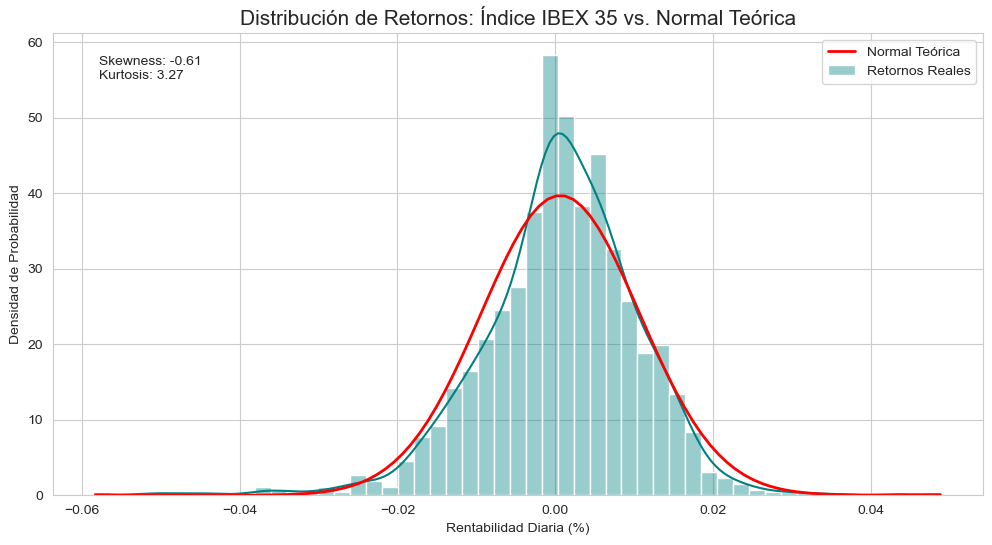

In [2]:
# Ejecutamos la funcion de el test 
resultado = test_normalidad(df_retornos['^IBEX'], 'IBEX 35')

# Imprimimos el reporte 
imprimir_reporte_normalidad(resultado)

# Primero calculamos los datos del test 
res_ibex = test_normalidad(df_retornos['^IBEX'], 'Índice IBEX 35')

# Llamamos a la funcion de la grafica 
graficar_distribucion(df_retornos['^IBEX'], res_ibex)



1. Ruptura de la Normalidad (p-value: 0.0000)
- Al ser el p-value menor a 0.05, rechazamos la hipótesis de que el IBEX siga una campana de Gauss.

 - Implicación: Los modelos financieros que asumen normalidad (como el ratio de Sharpe estándar) van a infraestimar el riesgo. El IBEX 35 no es un sistema "ordenado" y predecible estadísticamente.

2. Sesgo a la Izquierda (Asimetría: -0.59)
- Vemos que la "cola" izquierda es más larga que la derecha.

 - Conclusión: En el mercado español, el sentimiento de pánico es más fuerte que el de euforia. Las caídas son mucho más bruscas y rápidas que las subidas. Un inversor en el IBEX debe estar más preparado para un "crack" repentino que para un "rally" explosivo.

3. El peligro de las "Fat Tails" (Curtosis: 3.14)
- Una Curtosis de 3.14 (exceso sobre la normal) significa que la montaña es muy alta en el centro, pero las colas son muy gruesas.

 - Conclusión: Los "Cisnes Negros" (eventos extremos como el COVID o el Brexit) ocurren en el IBEX con una frecuencia 3 veces mayor de lo que nos diría la estadística normal.


> **Nota técnica:** La **curtosis de 3.14** confirma la presencia de **Fat Tails**. Esto significa que el riesgo de sufrir caídas extremas es mucho mayor de lo que los modelos estadísticos convencionales asumen.

## Análisis Comparativo por Sectores (Atribución de Riesgo)
- Objetivo: Determinar si la no-normalidad detectada en el índice general es un fenómeno sistémico o si, por el contrario, está impulsada por la dinámica específica de ciertos sectores económicos. Este análisis permite identificar los focos de riesgo extremo (Fat Tails) dentro del selectivo español.

Segmentación Sectorial: Se agrupan los activos según su clasificación industrial (Banca, Energía, Inmobiliario, etc.) para contrastar la estabilidad de sus distribuciones.

Métricas de Comparación: Se utiliza la Kurtosis Media y la Tasa de Rechazo de H0 por sector. Un sector con alta Kurtosis persistente se identifica como un "motor de inestabilidad" para el portfolio, asumiendo que sus movimientos extremos tienen un peso desproporcionado en la volatilidad total del índice.

In [3]:

summary_bancos, df_bancos = analizar_sector_normalidad(df_retornos, df_comp, 'Bancos y cajas de ahorro')
summary_energia, df_energia = analizar_sector_normalidad(df_retornos, df_comp, 'Electricidad y gas')

# Mostramos los resultados finales
if summary_bancos:
    print(f"RESULTADO SECTOR BANCOS")
    print(f"Kurtosis Media: {summary_bancos['kurtosis_media']:.2f}")
    print(f"Empresas: {summary_bancos['n_empresas']}")
    print(f"Empresas que cumplen Normalidad: {summary_bancos['porcentaje_normal']}%")
if summary_energia:
    print(f"\nRESULTADO SECTOR ENERGÍA")
    print(f"Kurtosis Media: {summary_energia['kurtosis_media']:.2f}")
    print(f"Empresas: {summary_energia['n_empresas']}")
    print(f"Empresas que cumplen Normalidad: {summary_energia['porcentaje_normal']}%")

RESULTADO SECTOR BANCOS
Kurtosis Media: 2.76
Empresas: 6
Empresas que cumplen Normalidad: 0.0%

RESULTADO SECTOR ENERGÍA
Kurtosis Media: 5.80
Empresas: 5
Empresas que cumplen Normalidad: 0.0%


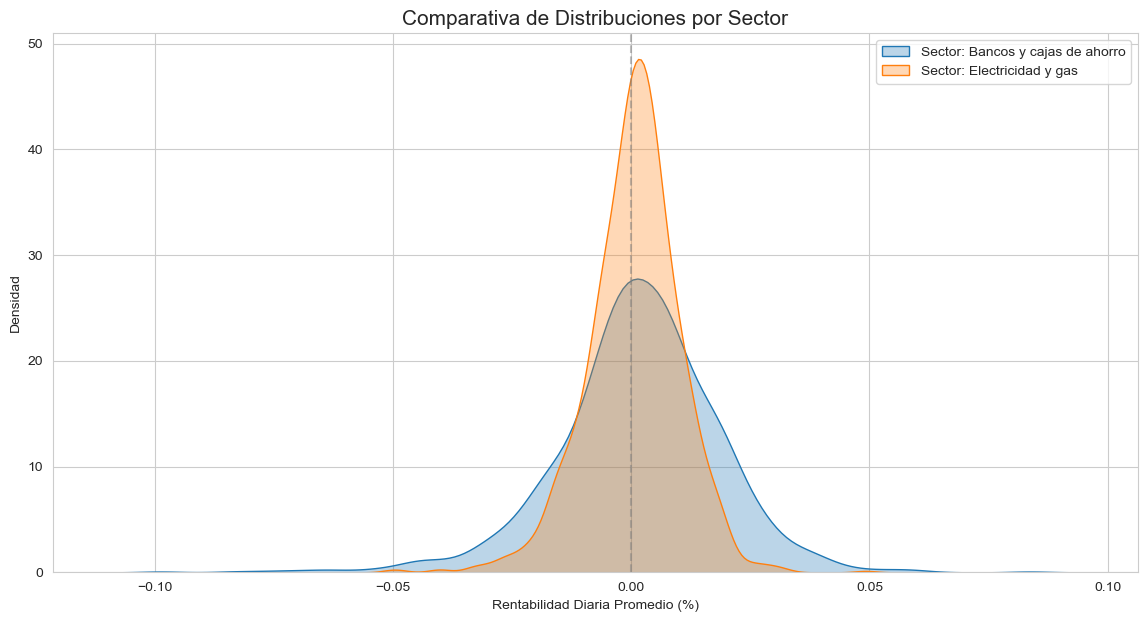

In [4]:
# Definimos los sectores que queremos contrastar
sectores_a_comparar = ['Bancos y cajas de ahorro', 'Electricidad y gas']
# Lanzamos la gráfica comparativa
graficar_comparativa_sectores(df_retornos, df_comp, sectores_a_comparar)

## Conclusiones Atribución de Riesgo por sectores Energia y Bancos

- Sector Energía (Naranja): Tiene una Curtosis muy alta. En la gráfica se ve  ese pico altísimo y estrecho.

 Significado: Los retornos de las eléctricas son extremadamente predecibles y  la mayor parte del tiempo están muy concentrados en el centro.
 El Riesgo: Cuando hay un movimiento, suele ser un "latigazo" extremo (cola pesada). 

- Sector Bancos (Azul): Tiene una Curtosis menor (2.77), más cercana a la normalidad en forma, pero es mucho más ancha.

 Significado: La base de la curva es mucho más extensa. Esto indica que los bancos tienen una volatilidad diaria constante mucho mayor. Un día "normal" en el sector bancario implica oscilaciones de precio mucho más grandes que en el energético.

- Confirmación de la No-Normalidad (0.0%)
Ni una sola empresa de estos sectores sigue una distribución normal.

Esto invalida el uso de métricas tradicionales como el VaR (Value at Risk) básico para el IBEX 35, ya que ambos sectores subestiman sistemáticamente la probabilidad de desastres financieros.

## Análisis de Dependencias: Matriz de Correlación

- Objetivo: Cuantificar el grado de relación lineal entre los retornos de los distintos activos del IBEX 35. En la gestión de carteras, la correlación es la métrica fundamental para la diversificación; activos con baja correlación permiten reducir el riesgo total sin sacrificar la rentabilidad esperada.

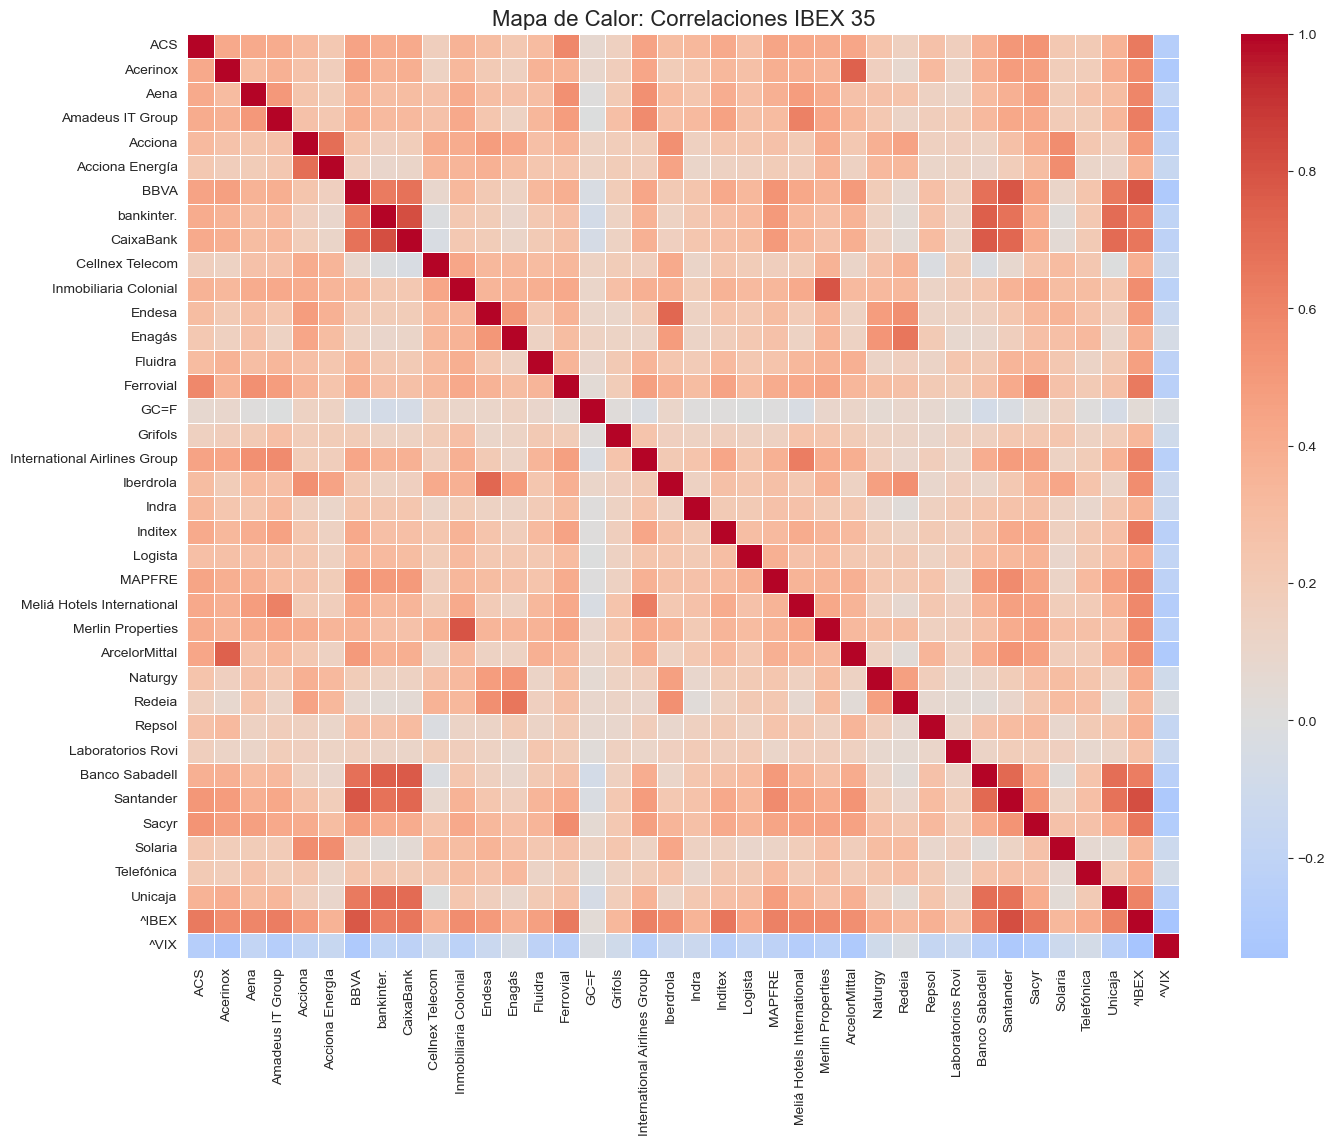

In [5]:
# Calculamos y graficamos la matriz de todos los retornos

matriz_corr = graficar_matriz_correlacion(df_retornos, df_comp=df_comp, titulo="Mapa de Calor: Correlaciones IBEX 35")

### Conclusión del Análisis de Correlación de Retornos


1. Riesgo Sistémico y Concentración Sectorial (Clúster Bancario)
Se observa una correlación positiva fuerte ($r \approx 0.85 - 0.95$) entre las entidades financieras del selectivo (BBVA, Bankinter, CaixaBank, Sabadell, Santander y Unicaja).

- Implicación: Existe una dependencia casi absoluta de este clúster ante variaciones en la política monetaria (BCE) y el ciclo de crédito. Para el inversor minorista, la tenencia simultánea de estos activos no representa una diversificación real, sino una exposición apalancada al riesgo financiero.

2. Dinámicas de Cobertura y Activos de Refugio (VIX y Oro)
El análisis confirma la correlación inversa (negativa) entre el índice de volatilidad (^VIX) y el ^IBEX 35.

Implicación: El VIX actúa como una métrica de "sentimiento de mercado", donde incrementos en la incertidumbre correlacionan con contracciones en los precios de renta variable. Asimismo, el Oro (GC=F) presenta una correlación cercana a cero con la mayoría de los activos, validando su rol como activo descorrelacionado y estabilizador en periodos de inestabilidad sistémica.

3. Independencia Estadística e Idiosincrasia (Oportunidades de Diversificación)
Ciertos activos, notablemente Cellnex (CLNX.MC) y Laboratorios Rovi (ROVI.MC), exhiben coeficientes de correlación sensiblemente inferiores a la media del mercado.

Implicación: Estos activos demuestran una mayor dependencia de su propia gestión operativa (riesgo idiosincrásico) que del comportamiento macroeconómico del índice. Su inclusión en una cartera de inversión es técnica indispensable para "enfriar" la volatilidad promedio y mejorar el ratio de Sharpe del conjunto.

## Análisis de Dependencias: Matriz de Correlación por Sector

- Objetivo: Cuantificar el grado de relación lineal entre los retornos de los distintos sectores del IBEX 35. En la gestión de carteras, la correlación es la métrica fundamental para la diversificación; activos con baja correlación permiten reducir el riesgo total sin sacrificar la rentabilidad esperada.

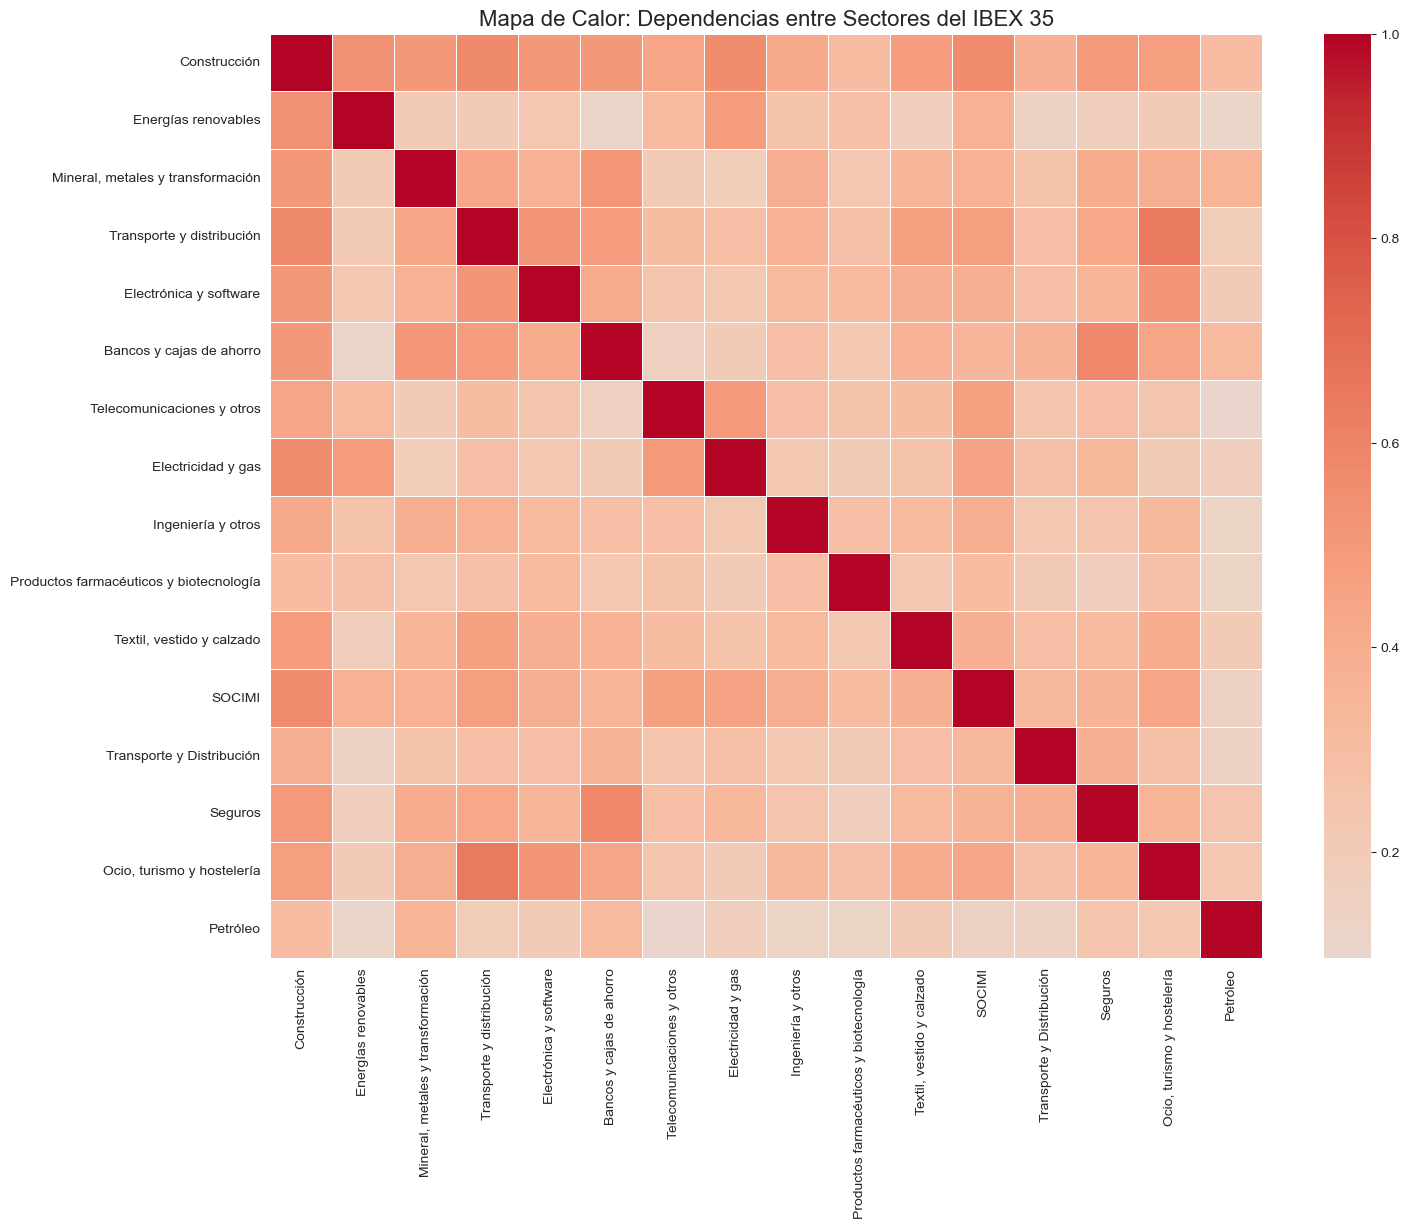

In [6]:
# Aseguramos que los nombres de los sectores estén limpios
df_comp['sector'] = df_comp['sector'].str.strip()

# Creamos un DataFrame vacío para los retornos sectoriales
df_retornos_sectoriales = pd.DataFrame(index=df_retornos.index)

# Calculamos el retorno promedio por cada sector
for sector in df_comp['sector'].unique():
    # Buscamos los tickers que pertenecen a este sector
    tickers = df_comp[df_comp['sector'] == sector]['ticker_yahoo'].tolist()
    # Filtramos solo los que tenemos en nuestro df_retornos
    tickers_validos = [t for t in tickers if t in df_retornos.columns]
    
    if tickers_validos:
        # El retorno del sector es la media de sus empresas
        df_retornos_sectoriales[sector] = df_retornos[tickers_validos].mean(axis=1)

# 4. Usamos la función graficar_matriz_correlacion para obtener la matriz 
matriz_sectorial = graficar_matriz_correlacion(df_retornos_sectoriales, "Mapa de Calor: Dependencias entre Sectores del IBEX 35")